<a href="https://colab.research.google.com/github/Rahulkr015451/Student-Performance-Analytics/blob/main/Student_Exam_Score_%26_Attendance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

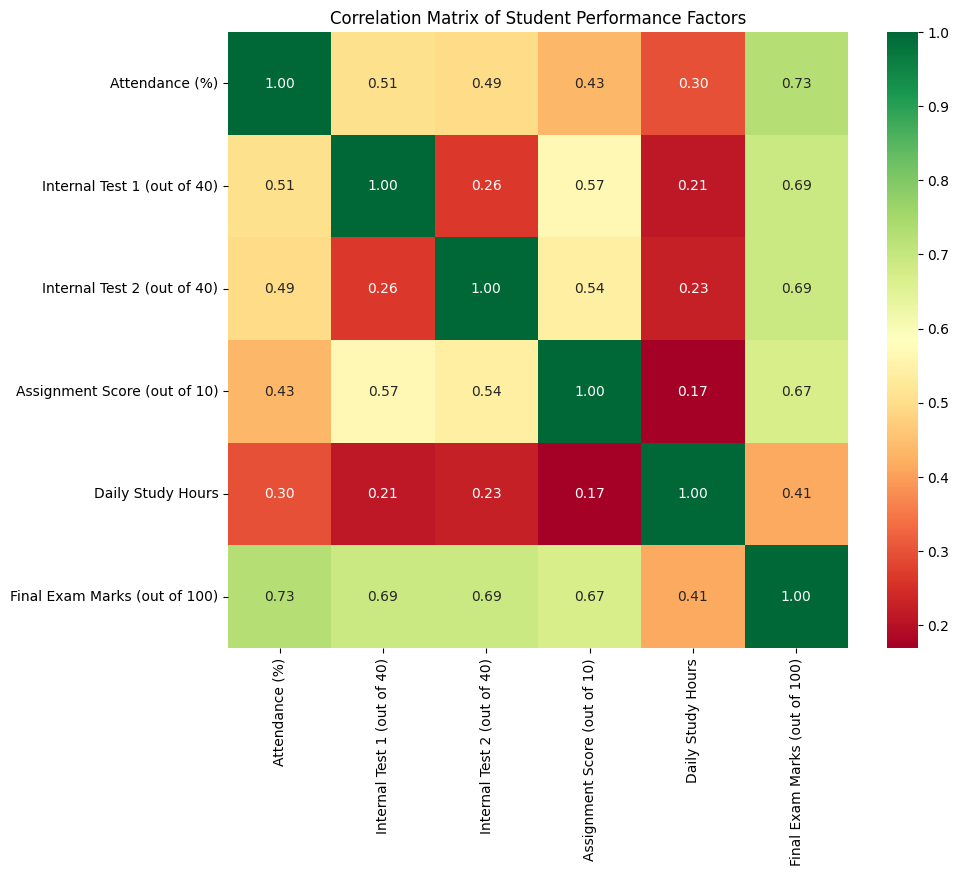

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Final_Marks_Data.csv')

# Calculate correlation
corr_matrix = df[['Attendance (%)', 'Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)',
                 'Assignment Score (out of 10)', 'Daily Study Hours', 'Final Exam Marks (out of 100)']].corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Matrix of Student Performance Factors')
plt.show()

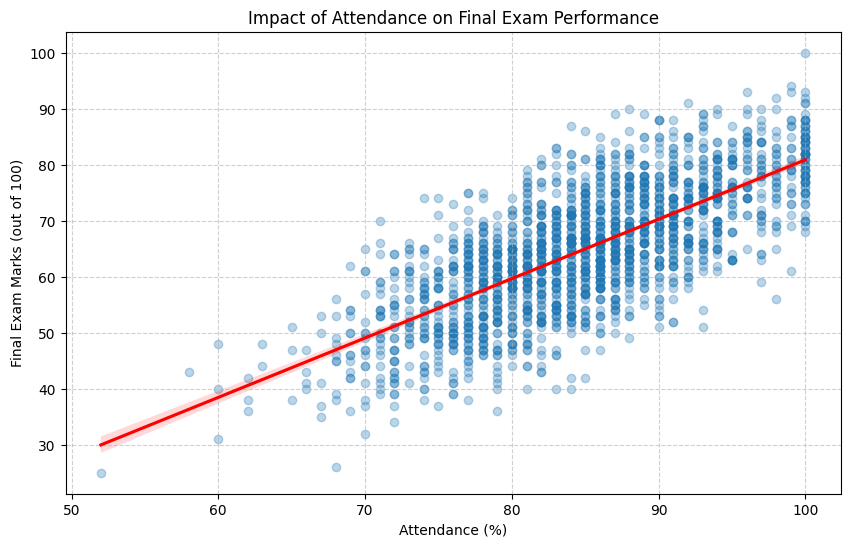

In [2]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Attendance (%)', y='Final Exam Marks (out of 100)', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impact of Attendance on Final Exam Performance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [3]:
# Grouping students by attendance tiers
def categorize_attendance(pct):
    if pct < 75: return 'Critical (<75%)'
    if pct < 85: return 'Standard (75-85%)'
    return 'Excellent (>85%)'

df['Attendance_Status'] = df['Attendance (%)'].apply(categorize_attendance)

# Average Marks per Tier
tier_analysis = df.groupby('Attendance_Status')['Final Exam Marks (out of 100)'].mean()
print("Average Final Marks by Attendance Tier:")
print(tier_analysis)

Average Final Marks by Attendance Tier:
Attendance_Status
Critical (<75%)      49.907104
Excellent (>85%)     71.158700
Standard (75-85%)    59.850843
Name: Final Exam Marks (out of 100), dtype: float64


In [4]:
from sklearn.linear_model import LinearRegression

X = df[['Attendance (%)']]
y = df['Final Exam Marks (out of 100)']

model = LinearRegression()
model.fit(X, y)

print(f"Prediction Formula: Score = ({model.coef_[0]:.2f} * Attendance) + ({model.intercept_:.2f})")
print(f"R-Squared Value: {model.score(X, y):.4f}")

Prediction Formula: Score = (1.06 * Attendance) + (-25.19)
R-Squared Value: 0.5266
